<img src="../../figs/holberton_logo.png" alt="logo" width="500"/>

# Price Prediction Analysis

## Project Goals

In this project, our aim is to create a machine learning model that can predict housing prices in California. By analyzing various factors such as location, number of rooms, income levels, and housing trends, we'll train our model to make predictions. The ultimate goal is to provide valuable insights to home buyers, sellers, and real estate investors, helping them make informed decisions in the dynamic California housing market.

## Key Steps

### Data Collection and Understanding:

- Obtain the California housing dataset, understand its features, and gain insights into the target variable (housing prices).


### Data Preprocessing:

- Handle missing values, if any.
- Normalize or standardize numerical features to ensure they have similar scales.
- Encode categorical variables if needed.


### Selecting Features and Preparing Data 

- Select relevant features that could affect housing prices.
- Divide the dataset into training and testing sets to evaluate the model's performance.

### Model Training:

- Implement linear regression using libraries like `scikit-learn`
- Train the model on the training dataset.

### Model Evaluation:

- Evaluate the model's performance using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.
- Analyze the residuals to ensure the model assumptions hold.


## Data Collection and Exploration

To initiate the development of a price prediction model for California housing using linear regression, we begin by obtaining the dataset and comprehending its attributes, focusing on the target variable, housing prices

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset
california_housing = fetch_california_housing(as_frame=True)

print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [2]:
# Convert the dataset to a DataFrame
california_df = pd.DataFrame(data=california_housing.data, columns=california_housing.feature_names)
california_df['target'] = california_housing.target

# Display the first few rows of the dataset
print(california_df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


### Normalize (Standardize) Numerical Features

The goal of this code is to standardize the numerical features in the California housing dataset. Standardization is crucial because it ensures that all numerical features have similar scales, which is important for many machine learning algorithms, including linear regression.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_features = california_df.drop('target', axis=1)  
scaled_numerical_features = scaler.fit_transform(numerical_features)
california_df[numerical_features.columns] = scaled_numerical_features
california_df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,4.526
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,3.585
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,3.521
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,3.413
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,3.422


### Split the Dataset into Training and Testing Set

After analyzing the correlation matrix and selecting relevant features, we'll proceed to divide the dataset into training and testing sets:

In [4]:
from sklearn.model_selection import train_test_split

# Select features and target variable
X = california_df.drop('target', axis=1)
y = california_df['target']

# Divide the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (16512, 8) (16512,)
Testing set shape: (4128, 8) (4128,)


In [5]:
# Importing the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Train the model on the training data
rf_regressor.fit(X_train, y_train)

# Predictions on the test data
y_pred_rf = rf_regressor.predict(X_test)


In [6]:
# Evaluate the model performance
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error (MSE) and R-squared
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Metrics:")
print("Mean Squared Error (MSE):", mse_rf)
print("R-squared (R2):", r2_rf)

Random Forest Regression Metrics:
Mean Squared Error (MSE): 0.25549776668540763
R-squared (R2): 0.805024407701793


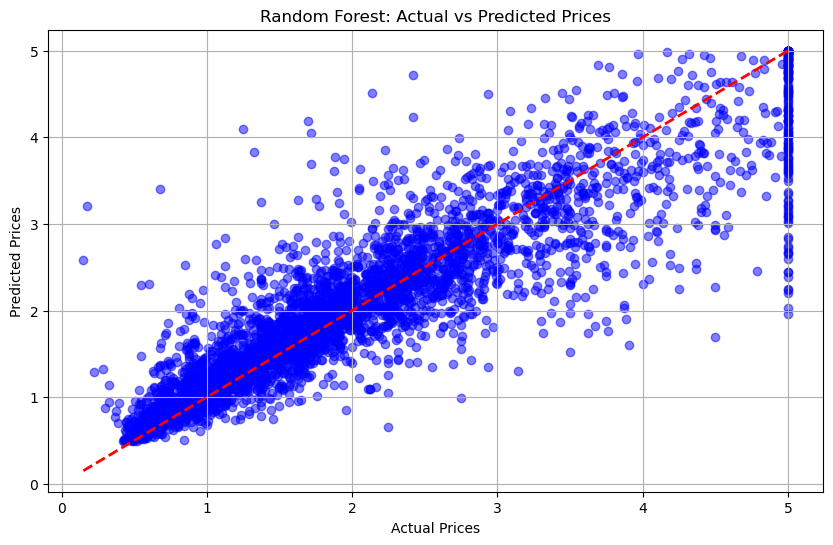

In [9]:
import matplotlib.pyplot as plt

# Plotting actual vs predicted prices for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Random Forest: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

In [7]:
# Importing the Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Regressor
gb_regressor = GradientBoostingRegressor(random_state=42)

# Train the model on the training data
gb_regressor.fit(X_train, y_train)

# Predictions on the test data
y_pred_gb = gb_regressor.predict(X_test)

In [8]:
# Calculate Mean Squared Error (MSE) and R-squared
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("\nGradient Boosting Regression Metrics:")
print("Mean Squared Error (MSE):", mse_gb)
print("R-squared (R2):", r2_gb)


Gradient Boosting Regression Metrics:
Mean Squared Error (MSE): 0.29399901242474274
R-squared (R2): 0.7756433164710084


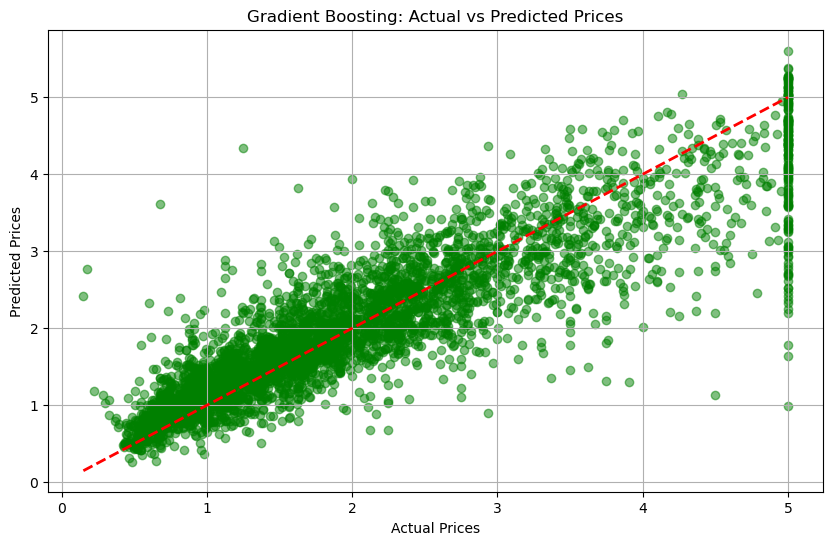

In [10]:
# Plotting actual vs predicted prices for Gradient Boosting
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_gb, color='green', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Gradient Boosting: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

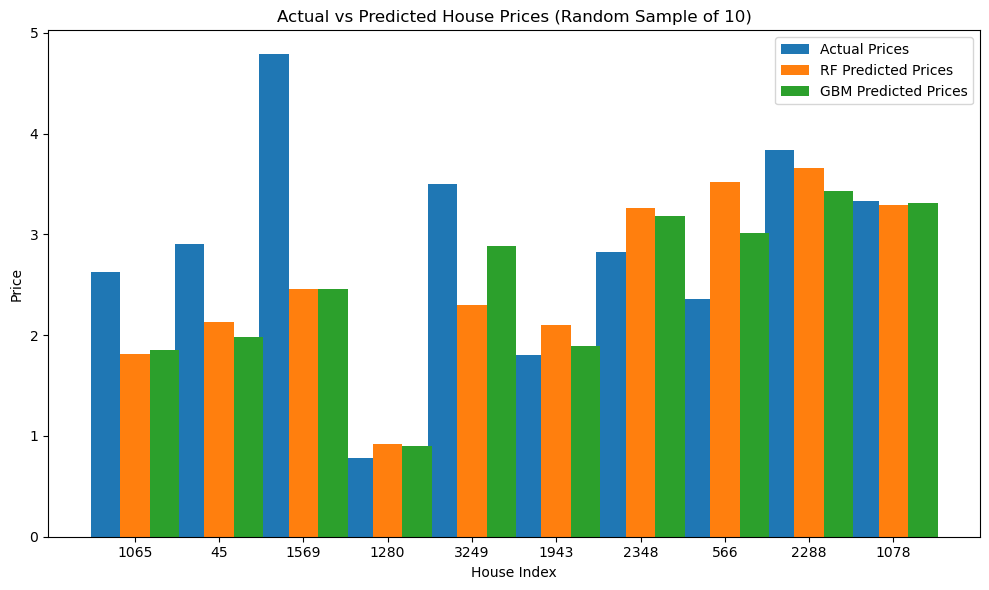

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Randomly select 10 indices from the test set
np.random.seed(0)  # for reproducibility
sample_indices = np.random.choice(len(y_test), size=10, replace=False)

# Get the actual prices and predicted prices for these 10 houses
actual_prices = y_test.iloc[sample_indices]
rf_predicted_prices = rf_regressor.predict(X_test.iloc[sample_indices])
gbm_predicted_prices = gb_regressor.predict(X_test.iloc[sample_indices])

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(sample_indices))

bar1 = ax.bar(index, actual_prices, bar_width, label='Actual Prices')
bar2 = ax.bar(index + bar_width, rf_predicted_prices, bar_width, label='RF Predicted Prices')
bar3 = ax.bar(index + 2*bar_width, gbm_predicted_prices, bar_width, label='GBM Predicted Prices')

ax.set_xlabel('House Index')
ax.set_ylabel('Price')
ax.set_title('Actual vs Predicted House Prices (Random Sample of 10)')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(sample_indices)
ax.legend()

plt.tight_layout()
plt.show()


In [15]:
from scipy.stats import zscore

# Calculate z-scores for the target variable
z_scores = zscore(california_df['target'])

# Define a threshold for outlier removal (e.g., 3 standard deviations)
threshold = 2
outlier_indices = np.abs(z_scores) > threshold

# Remove outliers from the dataframe
california_df_clean = california_df[~outlier_indices]

# Verify the shape of the cleaned dataset
print("Shape before removing outliers:", california_df.shape)
print("Shape after removing outliers:", california_df_clean.shape)


Shape before removing outliers: (20640, 9)
Shape after removing outliers: (19257, 9)


In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Separate features and target variable
X_clean = california_df_clean.drop('target', axis=1)
y_clean = california_df_clean['target']

# Divide the cleaned dataset into training and testing sets
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Initialize and train the models
rf_clean = RandomForestRegressor(random_state=42)
gbm_clean = GradientBoostingRegressor(random_state=42)

rf_clean.fit(X_train_clean, y_train_clean)
gbm_clean.fit(X_train_clean, y_train_clean)

# Predict on the test set
rf_clean_predictions = rf_clean.predict(X_test_clean)
gbm_clean_predictions = gbm_clean.predict(X_test_clean)

# Calculate RMSE for evaluation
rf_clean_mse = mean_squared_error(y_test_clean, rf_clean_predictions)
rf_clean_rmse = np.sqrt(mean_squared_error(y_test_clean, rf_clean_predictions))
gbm_clean_mse = mean_squared_error(y_test_clean, gbm_clean_predictions)
gbm_clean_rmse = np.sqrt(mean_squared_error(y_test_clean, gbm_clean_predictions))

print("Random Forest MSE after removing outliers:", rf_clean_mse)
print("Random Forest RMSE after removing outliers:", rf_clean_rmse)
print("Gradient Boosting MSE after removing outliers:", gbm_clean_mse)
print("Gradient Boosting RMSE after removing outliers:", gbm_clean_rmse)


Random Forest MSE after removing outliers: 0.17663555834401712
Random Forest RMSE after removing outliers: 0.42028033304452533
Gradient Boosting MSE after removing outliers: 0.20152731995165837
Gradient Boosting RMSE after removing outliers: 0.44891794345031294


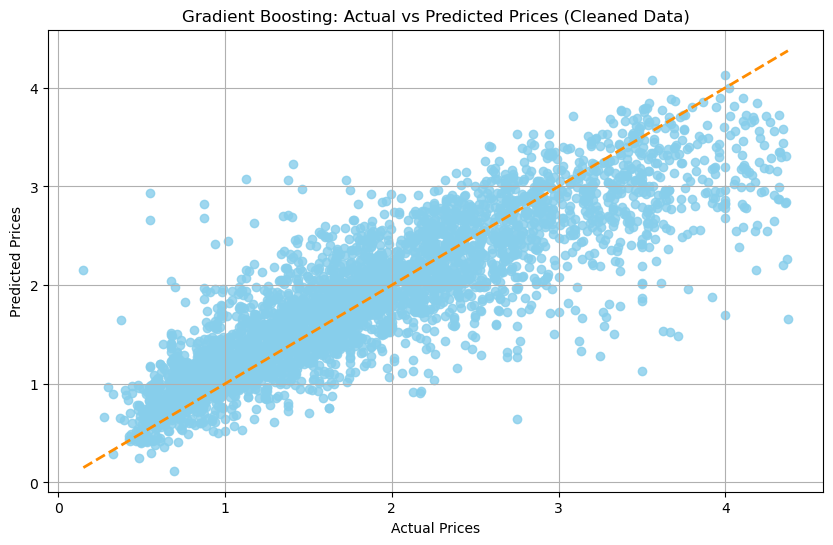

In [22]:
# Plotting actual vs predicted prices for Gradient Boosting
plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, gbm_clean_predictions, color='skyblue', alpha=0.8)
plt.plot([min(y_test_clean), max(y_test_clean)], [min(y_test_clean), max(y_test_clean)], color='darkorange', linestyle='--', lw=2)
plt.title('Gradient Boosting: Actual vs Predicted Prices (Cleaned Data)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

In [24]:
# Count the number of data points with a price equal to 5
outlier_count = california_df[california_df['target'] == 5].shape[0]
print(f"Number of data points with price equal to 5: {outlier_count}")



Number of data points with price equal to 5: 27


In [25]:
# Remove the outliers from the dataset
california_df_no_outliers = california_df[california_df['target'] != 5]

# Separate features and target variable
X_no_outliers = california_df_no_outliers.drop('target', axis=1)
y_no_outliers = california_df_no_outliers['target']

# Split the data into training and testing sets
X_train_no_outliers, X_test_no_outliers, y_train_no_outliers, y_test_no_outliers = train_test_split(
    X_no_outliers, y_no_outliers, test_size=0.2, random_state=42)

# Train the Random Forest Regressor on the cleaned data
rf_regressor_no_outliers = RandomForestRegressor(random_state=42)
rf_regressor_no_outliers.fit(X_train_no_outliers, y_train_no_outliers)

# Predictions on the test data
y_pred_rf_no_outliers = rf_regressor_no_outliers.predict(X_test_no_outliers)

# Calculate the error metrics
mse_rf_no_outliers = mean_squared_error(y_test_no_outliers, y_pred_rf_no_outliers)
r2_rf_no_outliers = r2_score(y_test_no_outliers, y_pred_rf_no_outliers)

print(f"Random Forest Regressor after removing outliers:")
print(f"Mean Squared Error (MSE): {mse_rf_no_outliers:.4f}")
print(f"Coefficient of Determination (R²): {r2_rf_no_outliers:.4f}")


Random Forest Regressor after removing outliers:
Mean Squared Error (MSE): 0.2561
Coefficient of Determination (R²): 0.8072
